## Desarrollo tarea HW Sesión 3

Felipe López Vergara

## 1. Regresión Simple
 
# ¿Cómo se relaciona la volatilidad con los retornos del mercado?

La volatilidad del mercado se puede medir a traves del indice VIX que refleja la expectativa de volatilidad del mercado a 30 días. Los retornos del mercado se pueden medir a traves del indice S&P 500 (ticker en yahoo finance ^GSPC). El VIX (ticker en yahoo finance ^VIX) es conocido como el índice del miedo porque cuando sube, los inversionistas esperan más incertidumbre o caídas en el mercado. Para responder la pregunta anterior, se puede realizar una regresión lineal simple entre la volatilidad del mercado y los retornos del mercado.


$\Delta VIX_t = \alpha + \beta \, r_{SP500,t} + \varepsilon_t$

Entender esta relacion es crucial para los inversionistas, ya que les permite anticipar movimientos del mercado y ajustar sus estrategias de inversión en consecuencia., por otro lado, ayuda a entender el comportamiento del mercado en periodos de stress.

Con la información anterior, debe hacer los siguientes pasos:

In [12]:
from matplotlib import pyplot as plt 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd 
import seaborn as sns
import yfinance as yf
import numpy as np

sns.set_style("dark")

1.Considere al menos 10 años de historia (frecuencia mensual) de los índices VIX y S&P 500.

In [4]:
#Descarga precios del VIX y el S&P 500 desde Yahoo Finance.

vix = yf.download('^VIX', start = '2016-01-01', end = '2026-01-01', progress = False)['Close']
sp500 = yf.download('^GSPC', start = '2016-01-01', end = '2026-01-01', progress = False)['Close']

#Frecuencia mensual
vix_mensual = vix.resample('ME').last()
sp500_mensual = sp500.resample('ME').last().pct_change()


2. Realice un scatterplot para visualizar la relación entre los dos índices e interprete lo que observa.

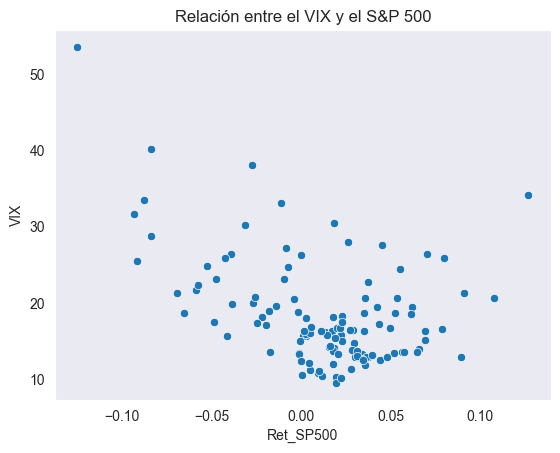

In [27]:
# Relación entre el VIX y el S&P 500

vix_mensual = vix_mensual.copy(); vix_mensual.name = 'VIX'
sp500_mensual = sp500_mensual.copy(); sp500_mensual.name = 'Ret_SP500'

df = pd.concat([sp500_mensual, vix_mensual], axis = 1).dropna()
df.columns = ['Ret_SP500', 'VIX']
df = df.reset_index(drop = True)

df.head()
sns.scatterplot(x = 'Ret_SP500', y = 'VIX', data = df)
plt.title('Relación entre el VIX y el S&P 500')
plt.show()

La relación del índice VIX que mide la expectativa de volatilidad esperada del índice S&P 500 a 30 dias y el retorno del S&P 500 es inversamente proporcional o tiene una correlación inversa, cuando disminuye el índice bursátil S&P 500 quiere decir que existe un aumento en la volatilidad e incertidumbre del mercado por lo que el índice VIX aumenta. Se observa además que la concentración de puntos se encuentra mayoritariamente bajo el umbral de los 20 puntos porcentuales del índice VIX que indica normalidad en el mercado.

Estime un modelo de regresión simple entre la volatilidad del mercado y los retornos del mercado

In [23]:
df.head()

,Ret_SP500,VIX
0,NaN,20.200001
1,-0.004128,20.549999
2,0.065991,13.950000
3,0.002699,15.700000
4,0.015325,14.190000


In [28]:
# Implementacion manual de estimadores

xbar = df['Ret_SP500'].mean()
ybar = df['VIX'].mean()

beta_1 = np.sum((df['Ret_SP500']-xbar)*(df['VIX']-ybar)) / np.sum((df['Ret_SP500'] - xbar)**2)
beta_0 = ybar - beta_1*xbar 

print(f"(intercepto): {beta_0:.4f}")
print(f"(pendiente): {beta_1:.4f}")

(intercepto): 19.2899
(pendiente): -69.5088


In [29]:
#Modelo vía Statmodels

modelo = smf.ols(formula = 'VIX ~ Ret_SP500', data = df).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    VIX   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     26.84
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           9.33e-07
Time:                        00:04:21   Log-Likelihood:                -387.36
No. Observations:                 119   AIC:                             778.7
Df Residuals:                     117   BIC:                             784.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.2899      0.600     32.130      0.000      18.101      20.479
Ret_SP500    -69.5088     13.417     -5.181      0.000     -96.080     -42.937
==============================================================================
Omnibus:                       43.306   Durbin-Watson:                   0.390
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               88.504
Skew:                           1.537   Prob(JB):                     6.05e-20
Kurtosis:                       5.899   Cond. No.                         23.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Interprete los resultados del modelo de regresión en el contexto financiero.

Algunos datos del modelo muetra que tiene un coefciente de -69.5088 quiere decir que si e S&P aumenta un 1% el índice VIX diminuye en 0.69 puntos. También que el R muetra que el retorno del S&P 500 explica aproximadamente el 18,7% la variabilidad del índice VIX. Al ser índices con relación inversa es consistente que en períodos de caídas bursátiles suelen estar asociados con aumentos en la incertidumbre y la volatilidad esperada del mercado (VIX).


5. Establezca una prueba de hipótesis para el parámetro de interés.

¿Explica índice S&P500 el precio de índice VIX ?

$H_0$ indica si el índicxe S&P500 no explica el precio del índice VIX y $H_1$ indica si el índicxe S&P500 tiene efecto sobre precio del índice VIX.

La prueba de Hipótesis es:

$H_0 : \beta = 0$
$H_1 : \beta \neq 0$

In [33]:
from scipy.stats import t

#Calculo del valor crítico t para un nivel de significancia del 5% 
df_resid = modelo.df_resid 
alpha = 0.05 
t_critico = t.ppf(1-alpha/2, df = df_resid)

print(f"Valor crítico t : {t_critico:.4f}")

Valor crítico t : 1.9804


6. Ajuste el modelo de regresión y muestre los resultados visualmente.

                            OLS Regression Results                            
Dep. Variable:                    VIX   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     26.84
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           9.33e-07
Time:                        01:29:13   Log-Likelihood:                -387.36
No. Observations:                 119   AIC:                             778.7
Df Residuals:                     117   BIC:                             784.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.2899      0.600     32.130      0.0

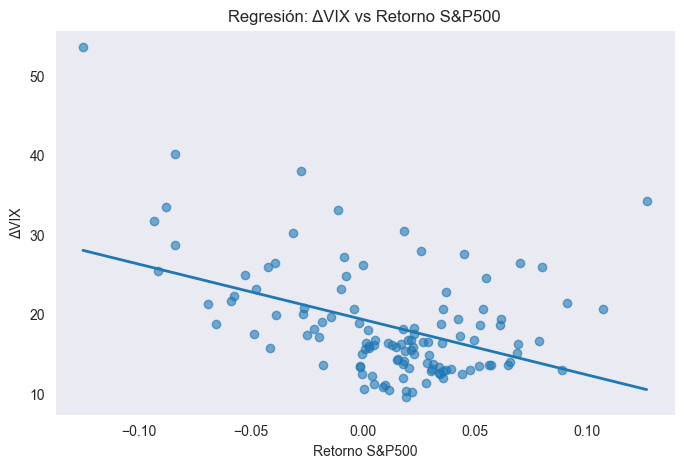

In [35]:
X = sm.add_constant(df['Ret_SP500'])
y = df['VIX']

model = sm.OLS(y, X).fit()

print(model.summary())

plt.figure(figsize=(8,5))
plt.scatter(df['Ret_SP500'], df['VIX'], alpha=0.6)

x_line = np.linspace(
    df['Ret_SP500'].min(),
    df['Ret_SP500'].max(),
    100
)

y_line = (
    model.params['const']
    + model.params['Ret_SP500'] * x_line
)

plt.plot(x_line, y_line, linewidth=2)
plt.xlabel('Retorno S&P500')
plt.ylabel('ΔVIX')
plt.title('Regresión: ΔVIX vs Retorno S&P500')
plt.show()

Se rechaza la hipótesis nula para un nivel de significancia si el verdadero valor del estadístico t cumple:

$$|t| > t_{n-k-1,\alpha/2}$$

$$|t_{\beta_1}| = |-5.181| = 5.181 > t_c = 1.9804$$

En este caso, el valor del estadístico de prueba t -5.123 en valor absoluto es mayor al valor crítico t de 1.984. Por lo tanto, se rechaza la hipótesis $H_0$ y existe la evidencia estadística que el $\beta_1$ es distinta de cero por lo que la variable del índice S&P500 tiene un efecto significativo sobre el índice VIX.

7.¿Qué tanto explica el SP500?

 El $R^2$ indica que el el modelo presenta un coeficiente de determinación de 0.187, es decir, que las variaciones del retorno del S&P 500 explican aproximadamente el 18,7 % de la variabilidad del VIX. El otro 81,3% se atribuye a factores externos al modelo como expectativas de los inversionistas, datos macroeconómicos, eventos geopolíticos o decisiones de política monetaria.


  